In [1]:
# ── Cell 1: Load & Prepare Time Series ───────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ── 1.1 Load ─────────────────────────────────────────────────────────────────
df = pd.read_csv("spatial_seer_all_rooms_v2.csv")
print(f"Raw shape: {df.shape}")
print(df[["room_label", "location", "noise_type", "scan_id"]].drop_duplicates().groupby("room_label")["location"].nunique())

# ── 1.2 Choose channels ───────────────────────────────────────────────────────
# GpuUtil and CpuUtil are your primary side-channel signals.
# FrameTimeStdDev, WorstFrameMs, MainThreadMs capture rendering variance.
# TotalUsedMem and CpuClockFreq add memory/frequency context.
# Battery/screen columns are excluded — too slow-changing to discriminate rooms.
CHANNELS = [
    "GpuUtil",
    "CpuUtil",
    "FrameTimeStdDev",
    "WorstFrameMs",
    "MainThreadMs",
    "TotalUsedMem",
    "CpuClockFreq",
]

# ── 1.3 Build per-scan time series array ─────────────────────────────────────
# Truncate all scans to a fixed length (shortest scan sets the floor)
scan_groups = df.groupby("scan_id")
SERIES_LEN = scan_groups.size().min()
print(f"\nTimesteps per scan — min: {scan_groups.size().min()}, max: {scan_groups.size().max()}, using: {SERIES_LEN}")

records = []
for scan_id, group in scan_groups:
    group = group.sort_values("Timestamp").iloc[:SERIES_LEN]
    meta = group.iloc[0][["room_label", "location", "noise_type", "device_id"]]
    ts = group[CHANNELS].values.T  # shape: (n_channels, series_len)
    records.append({
        "scan_id":    scan_id,
        "room_label": meta["room_label"],
        "location":   meta["location"],
        "noise_type": int(meta["noise_type"]),
        "device_id":  meta["device_id"],
        "ts":         ts,
    })

meta_df = pd.DataFrame([{k: v for k, v in r.items() if k != "ts"} for r in records])
X_raw   = np.stack([r["ts"] for r in records])   # (n_scans, n_channels, series_len)

print(f"\nX_raw shape : {X_raw.shape}  →  (scans, channels, timesteps)")
print(f"Scans       : {len(meta_df)}")
print(f"Room types  : {meta_df['room_label'].nunique()} — {sorted(meta_df['room_label'].unique())}")
print(f"Locations   : {meta_df['location'].nunique()} — {sorted(meta_df['location'].unique())}")

# ── 1.4 Encode labels ─────────────────────────────────────────────────────────
room_enc = LabelEncoder().fit(meta_df["room_label"])
loc_enc  = LabelEncoder().fit(meta_df["location"])

y_room = room_enc.transform(meta_df["room_label"])   # 4-class
y_loc  = loc_enc.transform(meta_df["location"])      # 16-class

print(f"\nRoom label mapping : {dict(zip(room_enc.classes_, room_enc.transform(room_enc.classes_)))}")
print(f"Location mapping   : {dict(zip(loc_enc.classes_, loc_enc.transform(loc_enc.classes_)))}")

Raw shape: (11268, 23)
room_label
conference    6
hallway       5
kitchen       4
lab           4
Name: location, dtype: int64

Timesteps per scan — min: 90, max: 91, using: 90

X_raw shape : (124, 7, 90)  →  (scans, channels, timesteps)
Scans       : 124
Room types  : 4 — ['conference', 'hallway', 'kitchen', 'lab']
Locations   : 19 — ['3211', '3215', '3310', '4001', '4211', '4213', '4214', '4218', '4307', 'CEEDKitchen', 'Floor2Kitchen', 'Floor3HallwayNearWorkArea', 'Floor3Kitchen', 'Floor4HallwayInFrontOf4214', 'Floor4Kitchen', 'InFrontOfCEEDHallway', 'Outside3102', 'Outside3410', 'privateeyelab']

Room label mapping : {'conference': np.int64(0), 'hallway': np.int64(1), 'kitchen': np.int64(2), 'lab': np.int64(3)}
Location mapping   : {'3211': np.int64(0), '3215': np.int64(1), '3310': np.int64(2), '4001': np.int64(3), '4211': np.int64(4), '4213': np.int64(5), '4214': np.int64(6), '4218': np.int64(7), '4307': np.int64(8), 'CEEDKitchen': np.int64(9), 'Floor2Kitchen': np.int64(10), 'Floor

Room-type CV accuracy:  0.7977 ± 0.0600
Per-fold:               [0.84   0.76   0.8    0.88   0.7083]

Classification Report (train set — for label inspection):
              precision    recall  f1-score   support

  conference       1.00      1.00      1.00        38
     hallway       1.00      1.00      1.00        26
     kitchen       1.00      1.00      1.00        28
         lab       1.00      1.00      1.00        32

    accuracy                           1.00       124
   macro avg       1.00      1.00      1.00       124
weighted avg       1.00      1.00      1.00       124



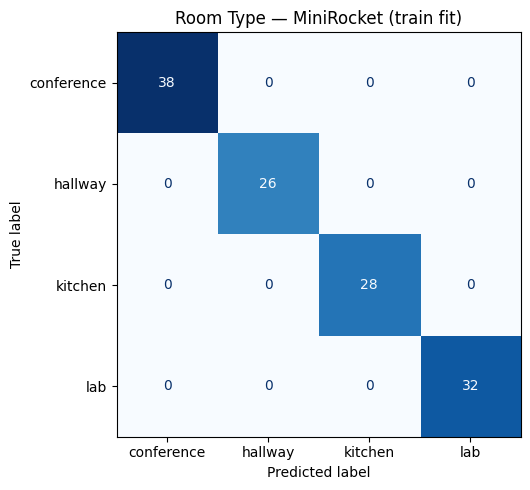

In [2]:
# ── Cell 2: Room Type Classification — Standard Train/Test Split ──────────────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Stratified 5-fold CV across scans (a room seen in training can appear in test)
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_rt = MiniRocketClassifier(random_state=42)

scores = cross_val_score(clf_rt, X_raw, y_room, cv=skf, scoring="accuracy", n_jobs=-1)
print(f"Room-type CV accuracy:  {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Per-fold:               {np.round(scores, 4)}")

# Fit on full data for the confusion matrix
clf_rt.fit(X_raw, y_room)
y_pred_room = clf_rt.predict(X_raw)

print("\nClassification Report (train set — for label inspection):")
print(classification_report(y_room, y_pred_room, target_names=room_enc.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_room, y_pred_room),
    display_labels=room_enc.classes_
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Room Type — MiniRocket (train fit)")
plt.tight_layout()
plt.show()

  Held out: 3211                      acc=1.0000  (n=2)
  Held out: 3215                      acc=0.6250  (n=8)
  Held out: 3310                      acc=1.0000  (n=6)
  Held out: 4001                      acc=0.2500  (n=8)
  Held out: 4211                      acc=0.3750  (n=8)
  Held out: 4213                      acc=0.5000  (n=8)
  Held out: 4214                      acc=0.0000  (n=8)
  Held out: 4218                      acc=0.1250  (n=8)
  Held out: 4307                      acc=0.5000  (n=6)
  Held out: CEEDKitchen               acc=0.1667  (n=6)
  Held out: Floor2Kitchen             acc=0.1667  (n=6)
  Held out: Floor3HallwayNearWorkArea acc=1.0000  (n=2)
  Held out: Floor3Kitchen             acc=1.0000  (n=8)
  Held out: Floor4HallwayInFrontOf4214 acc=0.8333  (n=6)
  Held out: Floor4Kitchen             acc=0.6250  (n=8)
  Held out: InFrontOfCEEDHallway      acc=1.0000  (n=6)
  Held out: Outside3102               acc=1.0000  (n=6)
  Held out: Outside3410               acc=1.000

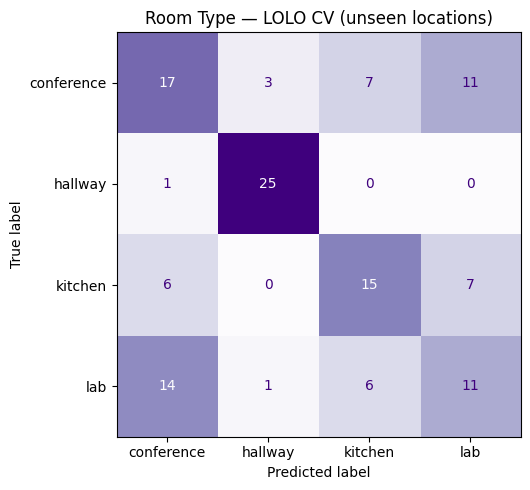

In [3]:
# ── Cell 3: Leave-One-Location-Out Cross-Validation ──────────────────────────
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score

logo   = LeaveOneGroupOut()
groups = meta_df["location"].values   # one group = one physical location

y_true_all, y_pred_all, fold_results = [], [], []

for fold, (train_idx, test_idx) in enumerate(logo.split(X_raw, y_room, groups)):
    X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
    y_tr, y_te = y_room[train_idx], y_room[test_idx]
    held_out_loc = groups[test_idx][0]

    clf = MiniRocketClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    fold_results.append({"held_out": held_out_loc, "accuracy": acc, "n_test": len(y_te)})
    y_true_all.extend(y_te)
    y_pred_all.extend(y_pred)
    print(f"  Held out: {held_out_loc:<25} acc={acc:.4f}  (n={len(y_te)})")

results_df = pd.DataFrame(fold_results)
print(f"\nLOLO mean accuracy : {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
print(f"Per room-type breakdown:")
print(results_df.groupby("held_out")["accuracy"].mean().sort_values())

# Aggregate confusion matrix across all folds
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_true_all, y_pred_all),
    display_labels=room_enc.classes_
).plot(ax=ax, colorbar=False, cmap="Purples")
ax.set_title("Room Type — LOLO CV (unseen locations)")
plt.tight_layout()
plt.show()

C:\Users\GayatriKamtala\Documents\spatial-seer-exports\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Location CV accuracy:  0.6207 ± 0.0836
Per-fold:              [0.72   0.52   0.56   0.72   0.5833]

Classification Report:
                            precision    recall  f1-score   support

                      3211       1.00      1.00      1.00         2
                      3215       1.00      1.00      1.00         8
                      3310       1.00      1.00      1.00         6
                      4001       1.00      1.00      1.00         8
                      4211       1.00      1.00      1.00         8
                      4213       1.00      1.00      1.00         8
                      4214       1.00      1.00      1.00         8
                      4218       1.00      1.00      1.00         8
                      4307       1.00      1.00      1.00         6
               CEEDKitchen       1.00      1.00      1.00         6
             Floor2Kitchen       1.00      1.00      1.00         6
 Floor3HallwayNearWorkArea       1.00      1.00      1.00   

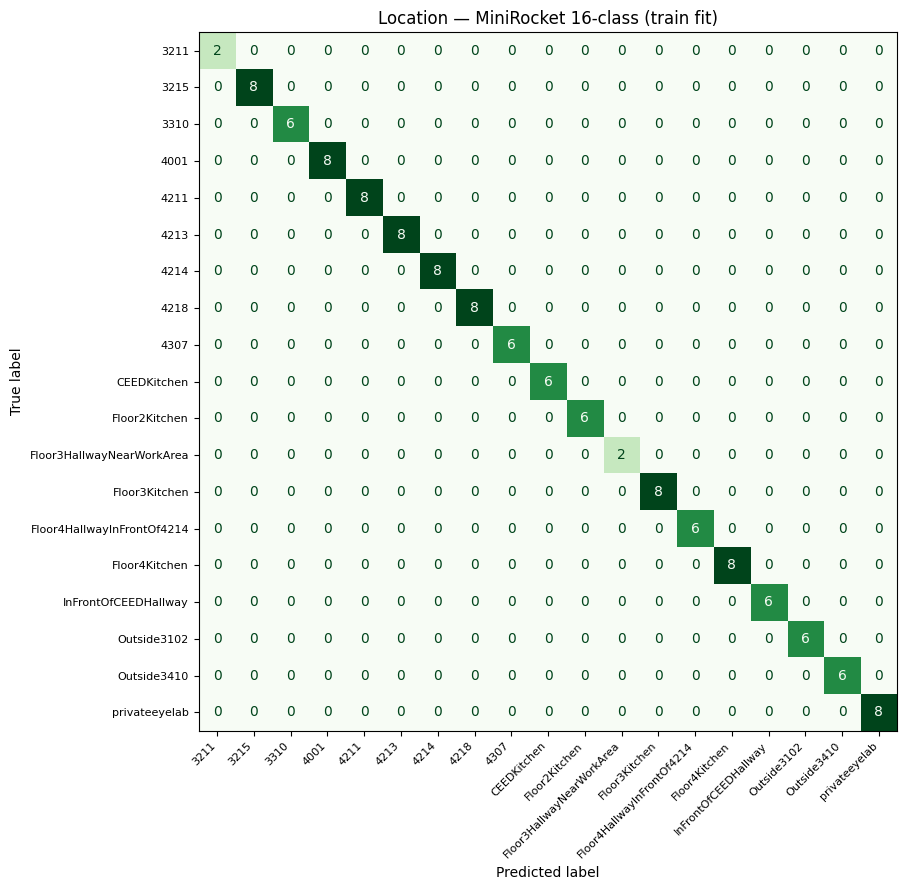

In [4]:
# ── Cell 4: Location Classification — 16-class ───────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

skf_loc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_loc = MiniRocketClassifier(random_state=42)

loc_scores = cross_val_score(clf_loc, X_raw, y_loc, cv=skf_loc, scoring="accuracy", n_jobs=-1)
print(f"Location CV accuracy:  {loc_scores.mean():.4f} ± {loc_scores.std():.4f}")
print(f"Per-fold:              {np.round(loc_scores, 4)}")

# Full fit for confusion matrix
clf_loc.fit(X_raw, y_loc)
y_pred_loc = clf_loc.predict(X_raw)

print("\nClassification Report:")
print(classification_report(y_loc, y_pred_loc, target_names=loc_enc.classes_))

fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay(
    confusion_matrix(y_loc, y_pred_loc),
    display_labels=loc_enc.classes_
).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Location — MiniRocket 16-class (train fit)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()